# Program to image converter 

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from math import sqrt, ceil

MAL_SAMPLE_PATH = "/Volumes/New Volume/malware-detection-dataset/malware/VirusShare_2c996fd0096c1b0ccba27496f5f8e6c0"
BEN_SAMPLE_PATH = "/Users/henrywilliams/Documents/programming/rust/checkers/target/x86_64-pc-windows-gnu/release/checkers.exe"


with open(BEN_SAMPLE_PATH, "rb") as file:
    benign_sample = file.read()

with open(MAL_SAMPLE_PATH, "rb") as file:
    malware_sample = file.read()

n_bytes_mal = len(malware_sample)
n_bytes_ben = len(benign_sample)
print("Malicious")
print(f"Size of executable:\t{n_bytes_mal} bytes")
print(f"\t\t\t{n_bytes_mal * 8} bits")
print("Benign")
print(f"Size of executable:\t{n_bytes_ben} bytes")
print(f"\t\t\t{n_bytes_ben * 8} bits")

Malicious

Size of executable:     6937880 bytes

55503040 bits

Benign

Size of executable:     7029235 bytes

56233880 bits

/var/folders/jd/lb_vbvw54zd00wp54hlkx4_m0000gn/T/ipykernel_88414/236422162.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


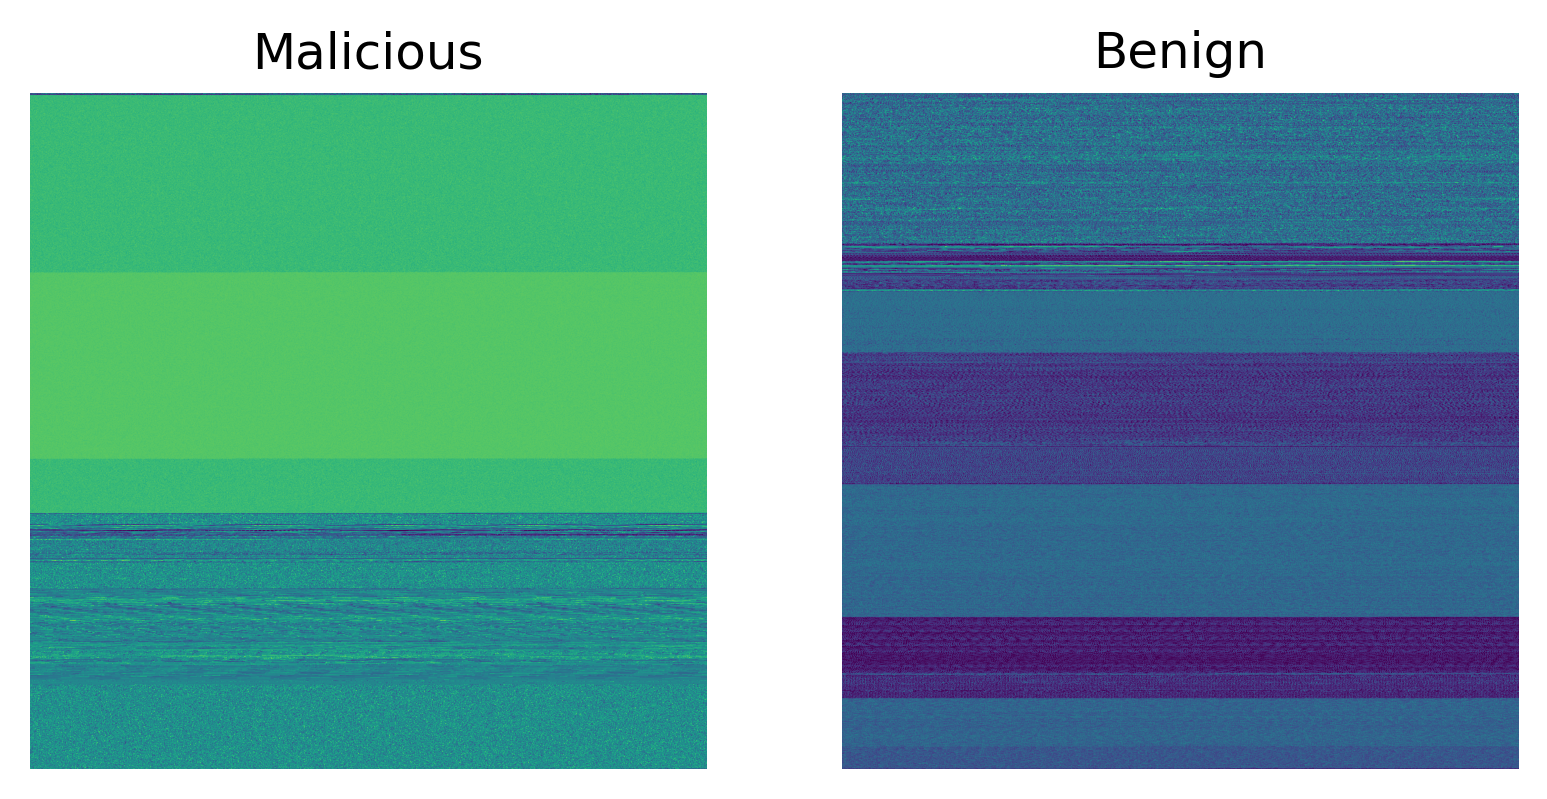

In [24]:
shape_mal = ceil(sqrt(n_bytes_mal))
padded_mal_sample = np.zeros(shape_mal**2)
padded_mal_sample[:n_bytes_mal] = list(malware_sample)


shape_ben = ceil(sqrt(n_bytes_ben))
padded_ben_sample = np.zeros(shape_ben**2)
padded_ben_sample[:n_bytes_ben] = list(benign_sample)
fig, axs = plt.subplots(1, 2, dpi=300)
axs[0].imshow(padded_mal_sample.reshape((shape_mal, shape_mal)) / 256)
axs[0].axis("off")
axs[0].title.set_text("Malicious")
axs[1].imshow(padded_ben_sample.reshape((shape_ben, shape_ben)) / 256)
axs[1].axis("off")
axs[1].title.set_text("Benign")
fig.show()

In [ ]:
def byte_to_bit_arr(b):
    a = [False] * 8
    for i in range(8):
        a[i] = bool(b & (1 << i))
    return a[::-1]


bin_img = np.zeros((shape**2, 8))

for i, (byte, pixels) in enumerate(zip(padded_sample, bin_img)):
    pixels = byte_to_bit_arr(int(byte))
    bin_img[i] = pixels


(bin_img.shape)

NameError: name 'shape' is not defined

([], [])

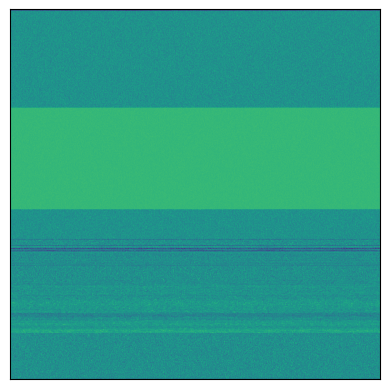

In [22]:
def bytes_to_binary_image(data: bytes) -> np.ndarray:
    """
    Converts a byte array into a binary (0 or 1) image.

    Parameters:
    data (bytes): The byte array to be converted.

    Returns:
    np.ndarray: A 2D binary image array (0s and 1s).
    """
    # Step 1: Convert bytes to a flat array of bits
    bit_array = np.unpackbits(np.frombuffer(data, dtype=np.uint8))

    # Step 2: Calculate the dimensions of the square image
    total_bits = len(bit_array)
    side_length = ceil(sqrt(total_bits))

    # Step 3: Pad the bit array with zeros if necessary to fill the image
    padded_bit_array = np.pad(
        bit_array, (0, side_length**2 - total_bits), mode="constant"
    )

    # Step 4: Reshape the bit array into a square image
    image = padded_bit_array.reshape((side_length, side_length))

    return image


plt.imshow(bytes_to_binary_image(malware_sample))
plt.xticks([])
plt.yticks([])